In [1]:
%run ../scripts/notebook_settings_lean.py
from scipy import stats
from horizonplot import horizonplot
from chromwindow import window
from ete3 import Tree

In [2]:
def create_paint_df_ind_compressed(df, ind, mapping, ns_map):
    d = {}
    max_pos = int(df.epos.iloc[-1])
    df = df.loc[df[ind].shift() != df[ind]].reset_index()
    df["epos"] = pd.concat([df.spos.iloc[1:], pd.Series(max_pos)], ignore_index=True)
    d["pos"] = df.spos
    d["end_pos"] = df.epos -1
    d["length"] = df.epos - df.spos
    d["reference"] = df[ind].map(mapping)
    d["n/s"] = d["reference"].map(ns_map)
    d["individual"] = ind[:-2]
    d["haplotype"] = ind[-1:]
    return pd.DataFrame(d)

def stairs(df, start='pos', end='end_pos', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])

In [3]:
df_l = []
for c in ["chr{}".format(x) for x in (range(1, 21))] + ["chrX"]:
    genetic_map = "/home/eriks/baboondiversity/data/PG_panu3_recombination_map/mikumi_pyrho_genetic_map_{}.txt"
    chr_recomb = pd.read_csv(genetic_map.format(c), sep=" ")
    df_l.append(chr_recomb)
recomb_df = pd.concat(df_l)

Time for the much more difficult case - Ruaha.

In [4]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_gm_focus/"
mapping_df = pd.read_csv(rfmix_path + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
    
north_south_mapping = {'Gog Woreda, Gambella region, Ethiopia': 1,
                         'Mikumi, Tanzania': 0}

df_l = []
for chrom in ["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

all_chrX
female_chrX
female_ref_chrX


In [5]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

In [6]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

ruaha = meta_data_samples.loc[meta_data_samples.Origin.isin(["Ruaha, Tanzania"])].PGDP_ID

df_ruaha = length_df.loc[length_df.individual.isin(ruaha)]
df = df_ruaha.loc[~(df_ruaha.individual.isin(male_IDs) & (df_ruaha.haplotype == "1"))]

In [7]:
c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")

df_l = []
for c in df.chrom.unique():
    print(c)
    l_df = df.loc[df.chrom == c].copy()
    if c.endswith("chrX"):
        c = "chrX"
    r_df = recomb_df.loc[(recomb_df.chromosome == c)]
    pos_mapping = dict(zip(r_df.position, r_df["Genetic_Map(cM)"]))
    l_df["start_cM"] = l_df.pos.map(pos_mapping)
    l_df["end"] = l_df.end_pos + 1
    l_df["end_cM"] = l_df.end.map(pos_mapping)
    call_df = c_r_g_df.loc[c_r_g_df.chrom == c]
    df_call_filt = []
    df_l.append(l_df)
df_r = pd.concat(df_l)
callable_df = call_df.loc[call_df.callable_frac > 0.75].reset_index()
c_s = callable_df.iloc[0].start
c_e, old_end = callable_df.iloc[0].start, 0
# Seems weird, but it makes it work correctly for identifying intervals in filters
r_s = callable_df.iloc[0].cM
sub_df_l, gap_df_l = [], []
for c in df_r["chrom"].unique():
    print(c)
    s_df = df_r.loc[df_r["chrom"] == c].copy()
    for i, row in callable_df.iterrows():
        if c_e != row.start:# or i+1 == len(callable_df):
            sub_df = s_df.loc[(s_df.end_pos > c_s) & (s_df.pos < c_e)]
            sub_df.loc[sub_df.start_cM < r_s, "start_cM"] = r_s
            sub_df.loc[sub_df.end_cM > row.end_cM, "end_cM"] = row.end_cM
            sub_df.loc[sub_df.pos < c_s, "pos"] = c_s
            sub_df.loc[sub_df.end_pos > c_e, "end_pos"] = c_e
            sub_df_l.append(sub_df)
            # Add start/ends
            start_df = sub_df.loc[sub_df.pos == c_s].copy()
            start_df.end_pos, start_df.end_cM, start_df.north = c_s, r_s, 0
            end_df = sub_df.loc[sub_df.end_pos == c_e].copy()
            end_df.pos, end_df.cM, end_df.north = c_e, r_s, 0
            gap_df_l.append(start_df), gap_df_l.append(end_df)
            # update df_l with new slice of fragment_df
            c_s, c_e, r_s = row.start, row.end, row.cM
        else:
            c_e = row.end
df_filt = pd.concat(sub_df_l)
gap_df = pd.concat(gap_df_l)

all_chrX
female_chrX
female_ref_chrX
all_chrX
female_chrX
female_ref_chrX


In [8]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "all_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.288703
PD_0214,0.298990
PD_0215,0.313808
PD_0216,0.254132
PD_0217,0.267857
PD_0503,0.267748


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


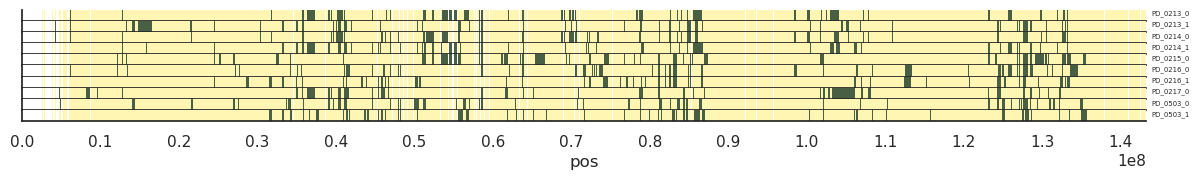

In [9]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [10]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "female_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.250569
PD_0214,0.280973
PD_0216,0.214765
PD_0503,0.232019


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


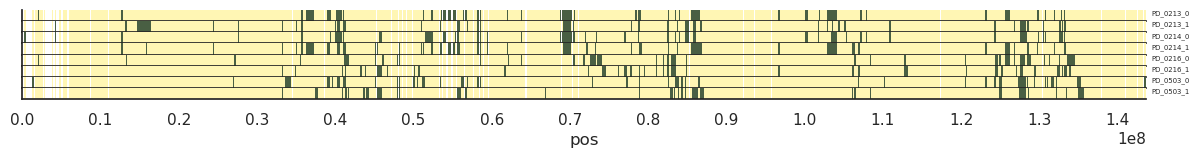

In [11]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [12]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "female_ref_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.315789
PD_0214,0.326007
PD_0215,0.340996
PD_0216,0.282883
PD_0217,0.295276
PD_0503,0.289963


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


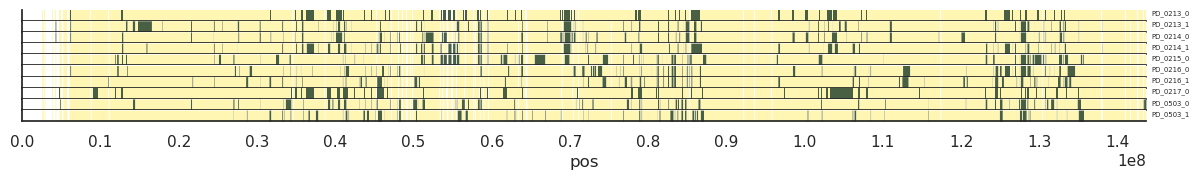

In [13]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [14]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_gm_focus_plain/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
    
north_south_mapping = {'Gog Woreda, Gambella region, Ethiopia': 1,
                         'Mikumi, Tanzania': 0}

df_l = []
for chrom in ["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

all_chrX
female_chrX
female_ref_chrX


In [15]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

In [16]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

ruaha = meta_data_samples.loc[meta_data_samples.Origin.isin(["Ruaha, Tanzania"])].PGDP_ID

df_ruaha = length_df.loc[length_df.individual.isin(ruaha)]
df = df_ruaha.loc[~(df_ruaha.individual.isin(male_IDs) & (df_ruaha.haplotype == "1"))]

In [17]:
c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")

df_l = []
for c in df.chrom.unique():
    print(c)
    l_df = df.loc[df.chrom == c].copy()
    if c.endswith("chrX"):
        c = "chrX"
    r_df = recomb_df.loc[(recomb_df.chromosome == c)]
    pos_mapping = dict(zip(r_df.position, r_df["Genetic_Map(cM)"]))
    l_df["start_cM"] = l_df.pos.map(pos_mapping)
    l_df["end"] = l_df.end_pos + 1
    l_df["end_cM"] = l_df.end.map(pos_mapping)
    call_df = c_r_g_df.loc[c_r_g_df.chrom == c]
    df_call_filt = []
    df_l.append(l_df)
df_r = pd.concat(df_l)
callable_df = call_df.loc[call_df.callable_frac > 0.75].reset_index()
c_s = callable_df.iloc[0].start
c_e, old_end = callable_df.iloc[0].start, 0
# Seems weird, but it makes it work correctly for identifying intervals in filters
r_s = callable_df.iloc[0].cM
sub_df_l, gap_df_l = [], []
for c in df_r["chrom"].unique():
    print(c)
    s_df = df_r.loc[df_r["chrom"] == c].copy()
    for i, row in callable_df.iterrows():
        if c_e != row.start:# or i+1 == len(callable_df):
            sub_df = s_df.loc[(s_df.end_pos > c_s) & (s_df.pos < c_e)]
            sub_df.loc[sub_df.start_cM < r_s, "start_cM"] = r_s
            sub_df.loc[sub_df.end_cM > row.end_cM, "end_cM"] = row.end_cM
            sub_df.loc[sub_df.pos < c_s, "pos"] = c_s
            sub_df.loc[sub_df.end_pos > c_e, "end_pos"] = c_e
            sub_df_l.append(sub_df)
            # Add start/ends
            start_df = sub_df.loc[sub_df.pos == c_s].copy()
            start_df.end_pos, start_df.end_cM, start_df.north = c_s, r_s, 0
            end_df = sub_df.loc[sub_df.end_pos == c_e].copy()
            end_df.pos, end_df.cM, end_df.north = c_e, r_s, 0
            gap_df_l.append(start_df), gap_df_l.append(end_df)
            # update df_l with new slice of fragment_df
            c_s, c_e, r_s = row.start, row.end, row.cM
        else:
            c_e = row.end
df_filt = pd.concat(sub_df_l)
gap_df = pd.concat(gap_df_l)

all_chrX
female_chrX
female_ref_chrX
all_chrX
female_chrX
female_ref_chrX


In [18]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "all_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.288703
PD_0214,0.298990
PD_0215,0.313808
PD_0216,0.254132
PD_0217,0.267857
PD_0503,0.267748


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


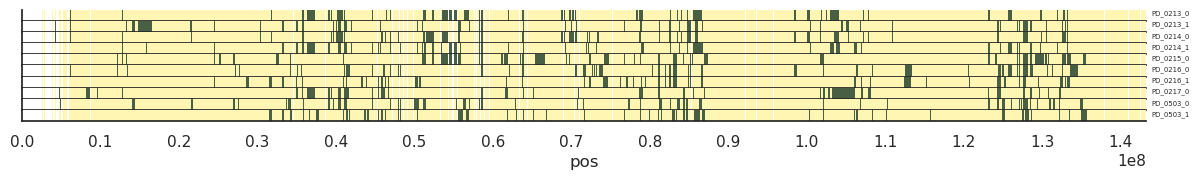

In [19]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [20]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "female_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.250569
PD_0214,0.280973
PD_0216,0.214765
PD_0503,0.232019


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


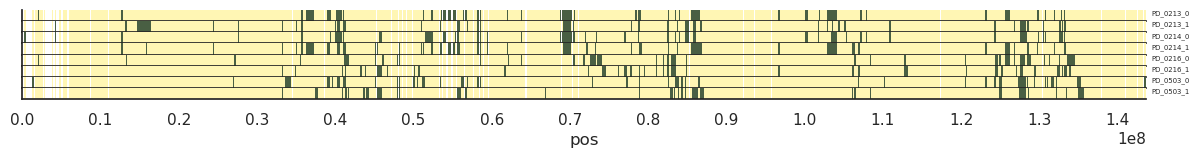

In [21]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [22]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "female_ref_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.315789
PD_0214,0.326007
PD_0215,0.340996
PD_0216,0.282883
PD_0217,0.295276
PD_0503,0.289963


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


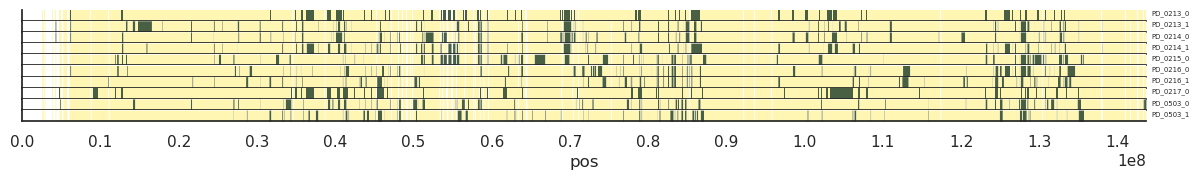

In [23]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))